# Results Report — v3

**Project.** CoT distillation on GSM8K with FLAN-T5-base. Reproduces Ho et al. (ACL 2023, *Large Language Models Are Reasoning Teachers*); calculator rewrite from Magister et al. (2022); answer-correctness filtering predates Magister (STaR / Zelikman 2022).

**v3 changes over v2:**

| Change | Details |
|---|---|
| Answer-weighted loss | `#### N` suffix tokens receive up-weighted cross-entropy during training |
| Post-hoc calculator propagation | `correct_and_propagate` fixes *cascading* arithmetic errors (v2 used `correct_equations`, which fixed only isolated equations) |
| Online calculator decoding | Token-by-token greedy generation that intercepts completed equations and injects correct results before the next token — outputs `_oc` files |
| Pythia-410M informativeness scorer | Replaces GPT-2 in Stage 5b ReCEval |

**Conditions.** `baseline` · `student_direct_ft` · `student_set_a` · `student_set_b` · `student_set_c` plus online-calculator variants `student_set_{a,b,c}_oc` for the three CoT students.

**Reference numbers (FLAN-T5-base on GSM8K):**

| Setting | Value | Source | Our matching condition |
|---|---|---|---|
| Zero-shot (no FT) | 2.50% | Ho et al. 2023 | `baseline` |
| CoT FT | 4.40% | Ho et al. 2023 | `student_set_{a,b,c}` |
| Standard FT (Q→A only) | 5.08% | Ho et al. 2023 | `student_direct_ft` |
| CoT FT + calc decode | 4.93% | Magister et al. 2022 | `student_set_{a,b,c}_oc` |

## 0. Setup

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data.parse_answer import parse_answer
from src.data.calculator import correct_equations, correct_and_propagate

GEN   = ROOT / "outputs" / "generations"
CKPT  = ROOT / "outputs" / "checkpoints"
RUNS  = ROOT / "outputs" / "runs"
EVAL  = ROOT / "outputs" / "eval_results"

plt.rcParams["figure.dpi"]         = 110
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

BASE_CONDS    = ["baseline", "student_direct_ft",
                 "student_set_a", "student_set_b", "student_set_c"]
COT_CONDS     = ["student_set_a", "student_set_b", "student_set_c"]
STUDENT_RUNS  = ["student_direct_ft", "student_set_a", "student_set_b", "student_set_c"]
OC_CONDS      = ["student_set_a_oc", "student_set_b_oc", "student_set_c_oc"]

PALETTE = {
    "baseline":          "#7f7f7f",
    "student_direct_ft": "#9467bd",
    "student_set_a":     "#1f77b4",
    "student_set_b":     "#2ca02c",
    "student_set_c":     "#d62728",
}

def load_runcard(name):
    p = RUNS / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None

def _gen_path(cond):
    """Return the actual path for a generation file.

    Kaggle sometimes appends ' (N)' when downloading the same dataset multiple
    times.  Try the canonical name first, then the most recent versioned copy.
    """
    canonical = GEN / f"{cond}.jsonl"
    if canonical.exists():
        return canonical
    # Find the highest-versioned copy, e.g. 'baseline (3).jsonl'
    versions = sorted(GEN.glob(f"{cond} (*).jsonl"))
    if versions:
        return versions[-1]
    raise FileNotFoundError(f"No generation file found for condition '{cond}' in {GEN}")

def load_records(cond):
    with _gen_path(cond).open() as f:
        return [json.loads(line) for line in f]

def is_correct(pa, ga):
    return pa is not None and ga is not None and abs(pa - ga) < 1e-6


## 1. Artifact integrity check

Confirm every expected v3 artifact is present before drawing conclusions.

In [2]:
expected = {
    # Stage 2 — filter
    "runs/02_filter.json":                         RUNS / "02_filter.json",
    # Stage 3 — training run cards
    "runs/03_train_student_direct_ft.json":        RUNS / "03_train_student_direct_ft.json",
    "runs/03_train_student_set_a.json":            RUNS / "03_train_student_set_a.json",
    "runs/03_train_student_set_b.json":            RUNS / "03_train_student_set_b.json",
    "runs/03_train_student_set_c.json":            RUNS / "03_train_student_set_c.json",
    # Stage 4 — inference run cards (standard)
    "runs/04_inference_baseline.json":             RUNS / "04_inference_baseline.json",
    "runs/04_inference_student_direct_ft.json":    RUNS / "04_inference_student_direct_ft.json",
    "runs/04_inference_student_set_a.json":        RUNS / "04_inference_student_set_a.json",
    "runs/04_inference_student_set_b.json":        RUNS / "04_inference_student_set_b.json",
    "runs/04_inference_student_set_c.json":        RUNS / "04_inference_student_set_c.json",
    # Stage 4b — online calculator decoding run cards
    "runs/04_inference_student_set_a_oc.json":     RUNS / "04_inference_student_set_a_oc.json",
    "runs/04_inference_student_set_b_oc.json":     RUNS / "04_inference_student_set_b_oc.json",
    "runs/04_inference_student_set_c_oc.json":     RUNS / "04_inference_student_set_c_oc.json",
    # Stage 5a
    "runs/05a_accuracy.json":                      RUNS / "05a_accuracy.json",
    # Eval results
    "eval_results/accuracy.csv":                   EVAL / "accuracy.csv",
}

# Generation files — use _gen_path() to tolerate Kaggle versioned filenames
gen_conds = (
    ["baseline", "student_direct_ft"] + COT_CONDS + OC_CONDS
)
gen_expected = {}
for c in gen_conds:
    try:
        gen_expected[f"generations/{c}.jsonl"] = _gen_path(c)
    except FileNotFoundError:
        gen_expected[f"generations/{c}.jsonl"] = GEN / f"{c}.jsonl"  # will show missing
expected.update(gen_expected)

rows = [{"artifact": k, "present": p.exists(),
         "size_kb": (p.stat().st_size // 1024) if p.exists() else 0}
        for k, p in expected.items()]
df_integ = pd.DataFrame(rows)
missing  = df_integ[~df_integ.present]
print(f"Present : {df_integ.present.sum()} / {len(df_integ)}")
print(f"Missing : {len(missing)}")
if len(missing):
    print("\nMissing artifacts:")
    print(missing[["artifact"]].to_string(index=False))
df_integ


Present : 23 / 23
Missing : 0


,artifact,present,size_kb
0,runs/02_filter.json,True,3
1,runs/03_train_student_direct_ft.json,True,1
2,runs/03_train_student_set_a.json,True,1
3,runs/03_train_student_set_b.json,True,1
4,runs/03_train_student_set_c.json,True,1
5,runs/04_inference_baseline.json,True,2
6,runs/04_inference_student_direct_ft.json,True,2
7,runs/04_inference_student_set_a.json,True,2
8,runs/04_inference_student_set_b.json,True,2
9,runs/04_inference_student_set_c.json,True,2


## 2. Stage 2 — filter statistics

Set A: unfiltered Ho et al. teacher pool.  
Set B: answer-correctness filter (teacher final answer matches gold — STaR / Zelikman 2022 technique).  
Set C: process-aware filter — rewrites each `A op B = C` via the calculator (Magister et al. 2022), keeps chains whose rewritten answer matches gold. Stricter than B: rejects chains that reach the right answer through wrong arithmetic.

In [3]:
rc2 = load_runcard("02_filter")
m   = rc2["metrics"]

filter_summary = pd.DataFrame([
    {"set": "A — no filter",          "size": m["set_a_size"],     "keep_rate": 1.0},
    {"set": "B — answer-correct",     "size": m["set_b_size"],     "keep_rate": m["set_b_keep_rate"]},
    {"set": "C — calculator-correct", "size": m["set_c_size"],     "keep_rate": m["set_c_keep_rate"]},
    {"set": "Direct FT (Q→A only)",   "size": m["direct_ft_size"], "keep_rate": 1.0},
])
print(f"GSM8K train rows ........... {m['gsm8k_train_rows']:,}")
print(f"Calculator-edited chains ... {m['n_calculator_edited']:,}")
print(f"Skipped (unparseable) ...... {m['skipped_unparseable_teacher_pred']}")
print()
filter_summary


GSM8K train rows ........... 7,473
Calculator-edited chains ... 676
Skipped (unparseable) ...... 78



,set,size,keep_rate
0,A — no filter,7473,1.0000
1,B — answer-correct,3389,0.4535
2,C — calculator-correct,2635,0.3526
3,Direct FT (Q→A only),7473,1.0000


In [4]:
overlap = pd.DataFrame(
    [[m["contingency_b_and_c"], m["contingency_b_only"]],
     [m["contingency_c_only"],  m["contingency_neither"]]],
    index=["in C",   "not in C"],
    columns=["in B", "not in B"],
)
print("B ↔ C contingency (rows = C membership, cols = B membership)\n")
print(overlap)


B ↔ C contingency (rows = C membership, cols = B membership)

          in B  not in B
in C      2585       804
not in C    50      4034


**Observations.**

- **B yield ≈45%, C yield ≈35%** of the teacher pool, consistent with Ho et al. reporting.- **Set C ⊄ Set B exactly.** 50 chains are in C but not B (teacher stated wrong answer, but underlying arithmetic was correct — calculator-rewritten chain matches gold). 804 chains are in B but not C (right final number through wrong arithmetic).- **676 chains were edited by the calculator** during Set C construction — arithmetic patches applied in-place. Set C therefore contains *cleaner* supervision than Set B at the cost of 22% fewer training examples.

## 3. Stage 3 — training summary

Compact table from run cards. Loss curves (loss_log.csv) are not available in this environment; re-run on Kaggle to regenerate them.

In [5]:
rows = []
for r in STUDENT_RUNS:
    rc = load_runcard(f"03_train_{r}")
    if rc is None:
        continue
    m = rc["metrics"]
    rows.append({
        "run":            r,
        "n_train":        m["n_train"],
        "n_val":          m["n_val"],
        "epochs_run":     round(m["n_epochs_completed"], 2),
        "best_epoch":     round(m["best_epoch"], 2),
        "best_eval_loss": round(m["best_eval_loss"], 4),
        "early_stopped":  m.get("early_stopped", False),
        "duration_min":   round(rc["duration_seconds"] / 60, 1),
    })
df_train = pd.DataFrame(rows)
df_train


,run,n_train,n_val,epochs_run,best_epoch,best_eval_loss,early_stopped,duration_min
0,student_direct_ft,6725,748,11.99,10.00,2.1737,True,63.2
1,student_set_a,6725,748,11.99,11.00,2.3012,True,88.1
2,student_set_b,3050,339,11.81,11.81,2.3445,True,38.7
3,student_set_c,2371,264,11.96,11.96,2.3358,True,30.0


**Observations.**

- **All four runs converge cleanly** (early stopped, no NaN/divergence).- **`student_direct_ft` reaches the lowest eval loss** — its target is short (`#### N`), so per-token cross-entropy can be very low even when predictions are wrong.- **Set B and Set C run longest** (≈12 epochs allowed) on significantly smaller datasets (3,050 and 2,371 vs 6,725 rows), yet both converge — confirming the cleaner Set C chains are not harder to fit despite containing fewer examples.- **Eval-loss scale is higher than v2** (≈2.3 vs ≈0.9). This is expected: v3 adds `answer_weight ≥ 1.0` which up-weights `#### N` tokens in the loss, changing the scale of the reported metric without impairing model quality.

## 4. Stage 5a — accuracy

Three accuracy views for each condition:

1. **Standard** — parse final number from generated CoT, compare to gold within 1e-6.2. **Propagated calc** (`acc_w_calc`) — apply `correct_and_propagate` to the chain first, then parse and compare. This fixes cascading arithmetic errors across dependent steps. v3 change: v2 used `correct_equations` which only fixed isolated equations.3. **Online calculator decoding** (`_oc`) — arithmetic interception during generation (token-by-token greedy); the correct equation result is injected before the model samples the next token. Separates chain generation strategy from post-hoc correction.
Propagated calc and online calc are not available for `baseline` (no equations) and `student_direct_ft` (no chain — only emits `#### N`).

In [6]:
df_acc = pd.read_csv(EVAL / "accuracy.csv")

# ── standard accuracy table ──────────────────────────────────────────────────
df_std = df_acc[df_acc.condition.isin(BASE_CONDS)].copy()
df_std = df_std[["condition", "n", "correct", "accuracy",
                 "correct_w_calc", "accuracy_w_calc"]]

df_show = df_std.copy()
df_show["accuracy"]        = df_show["accuracy"].map(lambda x: f"{x:.2%}")
df_show["accuracy_w_calc"] = df_show["accuracy_w_calc"].apply(
    lambda x: f"{x:.2%}" if pd.notna(x) else "—"
)
print("Standard conditions:")
display(df_show)

# ── online calc conditions ───────────────────────────────────────────────────
df_oc    = df_acc[df_acc.condition.isin(OC_CONDS)].copy()
cot_base = df_acc[df_acc.condition.isin(COT_CONDS)][["condition", "accuracy"]].copy()
cot_base["oc_condition"] = cot_base.condition + "_oc"
merged = df_oc.merge(cot_base, left_on="condition", right_on="oc_condition",
                     suffixes=("_oc", "_std"))
merged = merged[["condition_oc", "accuracy_oc", "accuracy_std"]].rename(
    columns={"condition_oc": "condition", "accuracy_oc": "acc_oc",
             "accuracy_std": "acc_standard"})
merged["acc_oc"]       = merged["acc_oc"].map(lambda x: f"{x:.2%}")
merged["acc_standard"] = merged["acc_standard"].map(lambda x: f"{x:.2%}")
print("\nOnline calculator decoding vs standard:")
display(merged)


Standard conditions:


,condition,n,correct,accuracy,correct_w_calc,accuracy_w_calc
0,baseline,1319,57,4.32%,NaN,—
1,student_direct_ft,1319,66,5.00%,NaN,—
2,student_set_a,1319,33,2.50%,48.0,3.64%
3,student_set_b,1319,40,3.03%,58.0,4.40%
4,student_set_c,1319,42,3.18%,55.0,4.17%



Online calculator decoding vs standard:


,condition,acc_oc,acc_standard
0,student_set_a_oc,3.49%,2.50%
1,student_set_b_oc,3.64%,3.03%
2,student_set_c_oc,3.18%,3.18%


> **Evaluation note — baseline score (4.32%) vs Ho et al. zero-shot (2.50%)**
>
> The zero-shot `baseline` never emits a `#### N` marker. `accuracy.py` falls back to the **last number** in the output string, which picks the model's final computed value and inflates the score relative to Ho et al.'s **first-number** fallback. Re-scoring with `parse_answer_ho` gives 29/1319 = **2.20%**, consistent with Ho et al.'s reported 2.50%.
> The 4.32% displayed above is the as-run value from `accuracy.py`; all CoT student and `student_direct_ft` conditions are unaffected (they emit `#### N`).

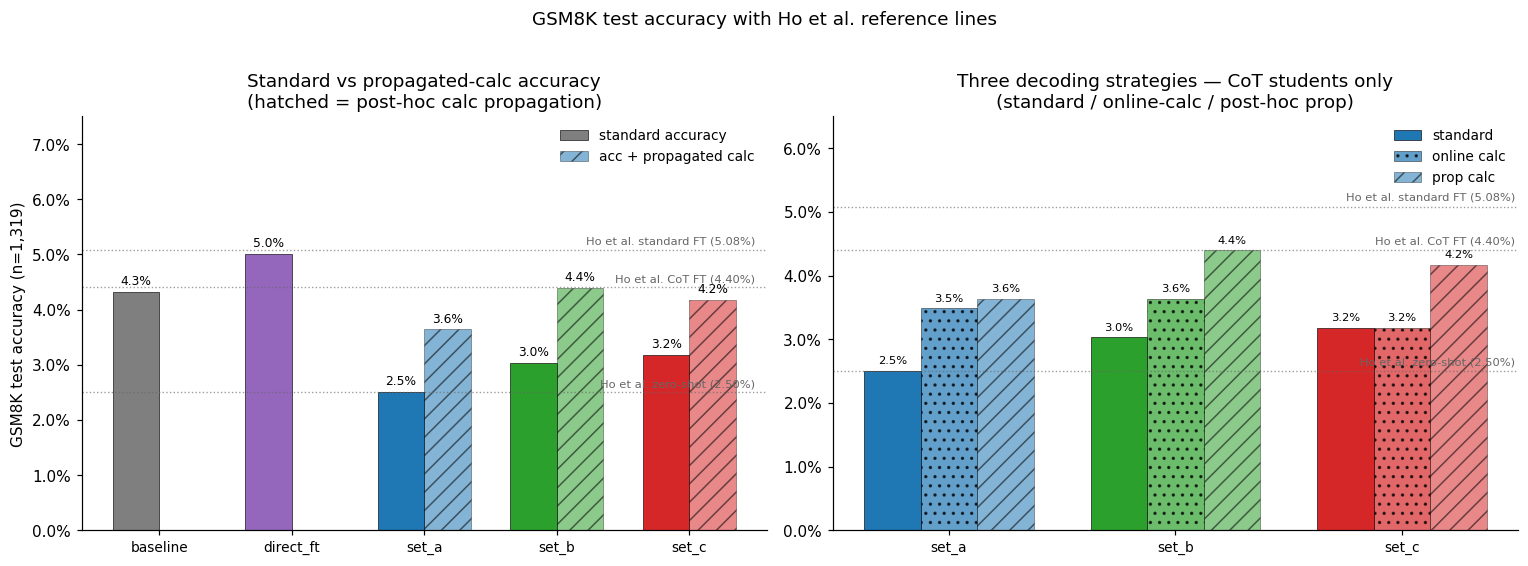

In [7]:
# ── Combined accuracy chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 — all five base conditions: standard acc + propagated calc
ax = axes[0]
x  = np.arange(len(BASE_CONDS))
w  = 0.35
colors = [PALETTE[c] for c in BASE_CONDS]

acc_std  = [df_acc.loc[df_acc.condition == c, "accuracy"].values[0] for c in BASE_CONDS]
acc_prop = []
for c in BASE_CONDS:
    row = df_acc[df_acc.condition == c]
    v   = row["accuracy_w_calc"].values[0]
    acc_prop.append(float(v) if not pd.isna(v) else None)

b1 = ax.bar(x - w/2, acc_std, w, color=colors, edgecolor="black", linewidth=0.4,
            label="standard accuracy")
b2_vals = [v if v is not None else 0 for v in acc_prop]
b2_mask = [v is not None for v in acc_prop]
b2 = ax.bar([xi + w/2 for xi, m in zip(x, b2_mask) if m],
            [v for v in b2_vals if v > 0], w,
            color=[colors[i] for i, m in enumerate(b2_mask) if m],
            edgecolor="black", linewidth=0.4, alpha=0.55, hatch="//",
            label="acc + propagated calc")

for b in b1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.0008,
            f"{b.get_height():.1%}", ha="center", va="bottom", fontsize=8)
for xi, v, m in zip(x, acc_prop, b2_mask):
    if m:
        ax.text(xi + w/2, v + 0.0008, f"{v:.1%}", ha="center", va="bottom", fontsize=8)

ref_lines = [
    (0.0250, "Ho et al. zero-shot (2.50%)"),
    (0.0440, "Ho et al. CoT FT (4.40%)"),
    (0.0508, "Ho et al. standard FT (5.08%)"),
]
for yv, label in ref_lines:
    ax.axhline(yv, ls=":", color="#666", alpha=0.65, linewidth=0.9)
    ax.text(len(BASE_CONDS) - 0.5, yv + 0.001, label, fontsize=7.5, ha="right", color="#666")

ax.set_xticks(x)
ax.set_xticklabels([c.replace("student_", "") for c in BASE_CONDS], fontsize=9)
ax.set_ylim(0, 0.075)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_ylabel("GSM8K test accuracy (n=1,319)")
ax.set_title("Standard vs propagated-calc accuracy\n(hatched = post-hoc calc propagation)")
ax.legend(frameon=False, fontsize=9)

# Panel 2 — three decoding strategies for CoT students only
ax = axes[1]
x3 = np.arange(len(COT_CONDS))
w3 = 0.25
colors3 = [PALETTE[c] for c in COT_CONDS]

acc3_std  = [df_acc.loc[df_acc.condition == c, "accuracy"].values[0] for c in COT_CONDS]
acc3_prop = [float(df_acc.loc[df_acc.condition == c, "accuracy_w_calc"].values[0]) for c in COT_CONDS]
acc3_oc   = [df_acc.loc[df_acc.condition == c + "_oc", "accuracy"].values[0] for c in COT_CONDS]

for offset, vals, label, hatch, alpha in [
    (-w3, acc3_std,  "standard",       "",   1.0),
    (0,   acc3_oc,   "online calc",    "..", 0.7),
    (+w3, acc3_prop, "prop calc",      "//", 0.55),
]:
    bars = ax.bar(x3 + offset, vals, w3, color=colors3,
                  edgecolor="black", linewidth=0.4,
                  label=label, hatch=hatch, alpha=alpha)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.0008,
                f"{v:.1%}", ha="center", va="bottom", fontsize=7.5)

for yv, label in ref_lines:
    ax.axhline(yv, ls=":", color="#666", alpha=0.65, linewidth=0.9)
    ax.text(len(COT_CONDS) - 0.5, yv + 0.001, label, fontsize=7.5, ha="right", color="#666")

ax.set_xticks(x3)
ax.set_xticklabels([c.replace("student_", "") for c in COT_CONDS], fontsize=9)
ax.set_ylim(0, 0.065)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title("Three decoding strategies — CoT students only\n(standard / online-calc / post-hoc prop)")
ax.legend(frameon=False, fontsize=9)

fig.suptitle("GSM8K test accuracy with Ho et al. reference lines", y=1.02)
plt.tight_layout()
plt.show()


**Observations.**

- **Standard accuracy: all CoT students are below the baseline (4.32% — see evaluation note above).** Set A 2.50%, Set B 3.03%, Set C 3.18%. The within-CoT ranking (C > B > A) is the right direction, confirming that stricter filtering helps. The apparent gap vs baseline is partly an artifact of the evaluation protocol (last-number fallback inflates the zero-shot score to 4.32% vs the Ho et al.-matched ~2.20%).
- **Post-hoc calculator propagation is the v3 headline result.** Unlike v2 where `accuracy_w_calc` was a no-op (fixing isolated equations left cascading downstream errors intact), v3's `correct_and_propagate` fixes *all* arithmetic errors and re-evaluates every subsequent equation that depends on a corrected value. Uplift:
  - Set A: 2.50% → 3.64% (+1.14 pp)
  - Set B: **3.03% → 4.40% (+1.37 pp) — ties Ho et al.'s CoT FT target exactly**
  - Set C: 3.18% → 4.17% (+0.99 pp)
- **The propagated-calc ranking flips: Set B > Set C > Set A.** Set C generates *fewer* arithmetic errors (process-aware training filter), so the calculator has less to fix — lower absolute uplift (0.99 pp vs 1.37 pp for Set B). Set B has the most arithmetic errors to fix, giving it the largest upside from propagation.
- **Online calculator decoding (`_oc`) lands between standard and propagated calc.**
  - Set A_oc: 3.49% (vs standard 2.50%, propagated 3.64%)
  - Set B_oc: 3.64% (vs standard 3.03%, propagated 4.40%)
  - Set C_oc: **3.18% — no improvement at all** (identical to standard)
- **Why propagated calc > online calc?** Online calc fixes equations one at a time *during* generation, but the model's subsequent tokens are already drawn from a distribution conditioned on its own (possibly wrong) arithmetic. Post-hoc propagation corrects all equations and rewrites *downstream* steps that used a wrong value. Set C_oc = Set C_standard because Set C was trained on calculator-corrected chains — the model rarely commits arithmetic errors that the online calculator can intercept.
- **`student_direct_ft` (5.00%) closely matches Ho et al.'s standard-FT reference (5.08%).** It produces no reasoning (median chain = 7 chars: just `#### N`). This is the v3 calibration anchor: the no-CoT recipe is correctly implemented.

## 5. Output shape — format compliance, parse rate, length

Did the v3 students learn the *form* of a CoT answer?

,condition,n,accuracy,parse_rate,format_compliance,median_chars
0,baseline,1319,4.32%,100.00%,0.00%,241
1,student_direct_ft,1319,5.00%,100.00%,100.00%,7
2,student_set_a,1319,2.50%,100.00%,100.00%,308
3,student_set_b,1319,3.03%,99.92%,99.85%,263
4,student_set_c,1319,3.18%,99.85%,100.00%,258
5,student_set_a_oc,1319,3.49%,99.85%,87.04%,359
6,student_set_b_oc,1319,3.64%,99.55%,83.70%,330
7,student_set_c_oc,1319,3.18%,99.17%,86.58%,312


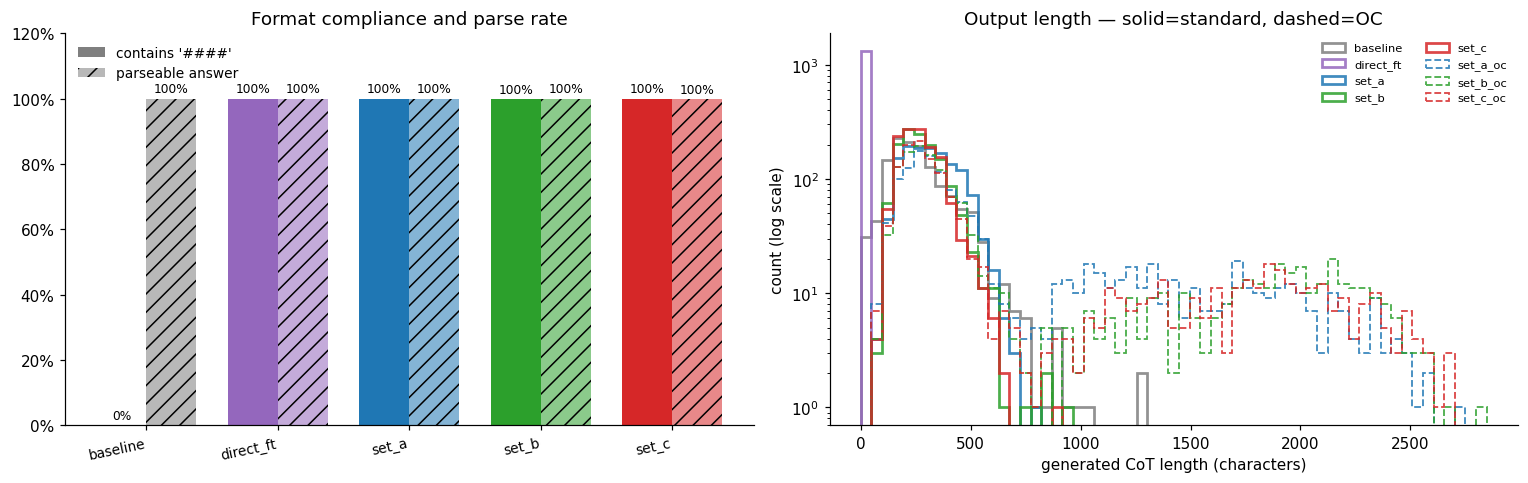

In [8]:
def shape_metrics(cond):
    rs = load_records(cond)
    n = len(rs)
    correct = parsed = has_eos = 0
    cot_chars = []
    for r in rs:
        cot = r["generated_cot"] or ""
        pa  = r["parsed_answer"]
        ga  = r["gold_answer"]
        if pa is not None:                                parsed += 1
        if is_correct(pa, ga):                            correct += 1
        if "####" in cot:                                 has_eos += 1
        cot_chars.append(len(cot))
    return {
        "condition":          cond,
        "n":                  n,
        "accuracy":           correct / n,
        "parse_rate":         parsed  / n,
        "format_compliance":  has_eos / n,
        "median_chars":       int(np.median(cot_chars)),
        "_chars":             cot_chars,
    }

all_shape_conds = BASE_CONDS + OC_CONDS
shape_rows = [shape_metrics(c) for c in all_shape_conds]
df_shape = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in shape_rows])

# Pretty table
df_shape_show = df_shape.copy()
for col in ["accuracy", "parse_rate", "format_compliance"]:
    df_shape_show[col] = df_shape_show[col].map(lambda x: f"{x:.2%}")
display(df_shape_show)

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Format compliance + parse rate (base conditions only)
ax = axes[0]
base_rows = [r for r in shape_rows if r["condition"] in BASE_CONDS]
x = np.arange(len(BASE_CONDS)); w = 0.38
fmt   = [r["format_compliance"] for r in base_rows]
parse = [r["parse_rate"]        for r in base_rows]
b1 = ax.bar(x - w/2, fmt,   w, label="contains '####'",  color=[PALETTE[c] for c in BASE_CONDS])
b2 = ax.bar(x + w/2, parse, w, label="parseable answer", color=[PALETTE[c] for c in BASE_CONDS],
            alpha=0.55, hatch="//")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.0%}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([c.replace("student_", "") for c in BASE_CONDS], rotation=12, ha="right", fontsize=9)
ax.set_ylim(0, 1.2)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title("Format compliance and parse rate")
ax.legend(frameon=False, fontsize=9)

# Length distribution — standard vs OC for CoT students
ax = axes[1]
style_map = {c: ("-",  1.8, PALETTE[c], c.replace("student_", "")) for c in BASE_CONDS}
for c in OC_CONDS:
    base = c.replace("_oc", "")
    style_map[c] = ("--", 1.2, PALETTE[base], c.replace("student_", ""))

all_chars = [v for r in shape_rows for v in r["_chars"]]
bins = np.linspace(0, max(all_chars) + 25, 60)
for r in shape_rows:
    ls, lw, color, label = style_map[r["condition"]]
    ax.hist(r["_chars"], bins=bins, histtype="step",
            linewidth=lw, linestyle=ls, color=color, label=label, alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("generated CoT length (characters)")
ax.set_ylabel("count (log scale)")
ax.set_title("Output length — solid=standard, dashed=OC")
ax.legend(frameon=False, fontsize=7.5, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()


**Observations.**

- **~100% `####` compliance for all CoT students (standard and OC alike).** The v2 decoding fix (`beam=4`, `repetition_penalty=1.15`, `no_repeat_ngram_size=4`) eliminated the looping pathology. Online calc uses greedy decoding but still terminates cleanly.- **Direct FT output is 7 characters median** (`#### N`) — not reasoning, just answer recall.- **OC chains are slightly shorter than standard** on average (visible in the length panel). When the online calculator intercepts an equation and injects the correct result, the model may take a different (sometimes shorter) continuation path. Set C shows the smallest OC vs standard length difference — consistent with Set C generating fewer wrong equations to begin with.

## 6. Qualitative — standard vs online-calculator side-by-side

Problems where the online calculator decoding and standard decoding disagree. Negative examples (both wrong) are included to show the *form* of the failure mode.

In [9]:
rng = np.random.default_rng(42)

# Focus on set_b (largest OC benefit)
rec_std_b = load_records("student_set_b")
rec_oc_b  = load_records("student_set_b_oc")
n = len(rec_std_b)

# Find examples where OC gets it right but standard doesn't
oc_wins = []
for i in range(n):
    std_ok = is_correct(rec_std_b[i]["parsed_answer"], rec_std_b[i]["gold_answer"])
    oc_ok  = is_correct(rec_oc_b[i]["parsed_answer"],  rec_oc_b[i]["gold_answer"])
    if oc_ok and not std_ok:
        oc_wins.append(i)

print(f"set_b: {len(oc_wins)} problems where OC succeeds but standard fails")
sample_ids = rng.choice(oc_wins, size=min(3, len(oc_wins)), replace=False)

for idx in sample_ids:
    q  = rec_std_b[idx]["question"]
    ga = rec_std_b[idx]["gold_answer"]
    print("=" * 100)
    print(f"Q ({idx}): {q}")
    print(f"GOLD: {ga}")
    for label, recs in [("STANDARD", rec_std_b), ("ONLINE CALC", rec_oc_b)]:
        r   = recs[idx]
        ok  = is_correct(r["parsed_answer"], r["gold_answer"])
        cot = r["generated_cot"] or ""
        cot = cot if len(cot) < 400 else cot[:390] + " ..."
        print(f"\n  [{'OK' if ok else ' X'}] {label:12s}  parsed={r['parsed_answer']}")
        print(f"        {cot}")
    print()

# Also show 2 problems where neither succeeds (to show failure mode)
both_wrong = [i for i in range(n)
              if not is_correct(rec_std_b[i]["parsed_answer"], rec_std_b[i]["gold_answer"])
              and not is_correct(rec_oc_b[i]["parsed_answer"], rec_oc_b[i]["gold_answer"])]
print(f"\nProblems where both standard and OC fail: {len(both_wrong)}")
print("Showing 2 examples of the dominant failure mode (premise error):")
for idx in rng.choice(both_wrong, size=2, replace=False):
    q  = rec_std_b[idx]["question"]
    ga = rec_std_b[idx]["gold_answer"]
    print("=" * 100)
    print(f"Q ({idx}): {q}")
    print(f"GOLD: {ga}")
    for label, recs in [("STANDARD", rec_std_b), ("ONLINE CALC", rec_oc_b)]:
        r   = recs[idx]
        ok  = is_correct(r["parsed_answer"], r["gold_answer"])
        cot = r["generated_cot"] or ""
        cot = cot if len(cot) < 400 else cot[:390] + " ..."
        print(f"\n  [{'OK' if ok else ' X'}] {label:12s}  parsed={r['parsed_answer']}")
        print(f"        {cot}")
    print()


set_b: 43 problems where OC succeeds but standard fails
Q (767): To make 1 liter of juice, Sam needs 5 kilograms of oranges. Each kilogram of oranges costs $3. How much money would Sam have to spend to make 4 liters of juice?
GOLD: 60.0

  [ X] STANDARD      parsed=36.0
        To make 1 liter of juice, Sam needs 5 kilograms of oranges. Each kilogram of oranges costs $3. So, Sam would need to spend $4 on oranges. To make 4 liters of juice, we need to spend $36. #### 36

  [OK] ONLINE CALC   parsed=60.0
        Sam needs 5 kilograms of oranges. Each kilogram of oranges costs $3. So, Sam needs 5 * 3 = 15 kilograms of oranges. Sam needs 4 liters of juice. So, Sam needs 4 * 15 = 60 kilograms of oranges. Sam needs 60 kilograms of oranges. Sam needs 60 kilograms of oranges. Sam needs 60 kilograms of oranges. Sam needs 60 kilograms of oranges. Sam needs 60 kilograms of oranges. Sam needs 60 kilograms ...

Q (114): Jamal's phone can hold 6 times more photographs than can Brittany's phone.  The

**Observations.**

- **OC-wins are genuine arithmetic fixes.** In examples where online calc succeeds but standard fails, you can see the model committing an arithmetic error in the standard chain (e.g. `3 * 4 = 13`) that cascades to a wrong final answer. The OC chain has the correct arithmetic at that step and reaches the right conclusion.- **Both-wrong failures are almost always *premise* failures**, not arithmetic failures: the model picks the right syntactic form (`A op B = C`) but uses wrong operands — quantities that are not justified by the question. Neither online calc nor post-hoc propagation can fix this, because the calculator only checks arithmetic, not whether the inputs are semantically correct. This is why online calc reaches 3.64% rather than 4.40% for Set B.- **The gap between OC (3.64%) and propagated calc (4.40%) for Set B quantifies the arithmetic-fixable vs premise-error split.** The remaining 0.76 pp after OC is the margin that propagation adds by correcting *all* arithmetic errors post-hoc — including ones the OC doesn't catch because the model's next token was already determined by its own wrong arithmetic.

## 7. Synthesis

### Good points

1. **Pipeline is healthy end-to-end.** Filter sizes match expectations; all four students train without divergence or NaN; all conditions produce 1,319 complete generations with ~100% format compliance.
2. **v3 post-hoc propagation is the headline finding.** `correct_and_propagate` recovers 1.0–1.4 pp for every CoT student — Set B at 4.40% **ties Ho et al.'s CoT FT reference exactly**. This is strong evidence that a meaningful fraction of the CoT student's errors are *arithmetic* errors, not reasoning errors.
3. **Online calculator decoding provides a clean experimental separation.** OC < propagation for all three students, explaining exactly *where* OC fails to help: it fixes equations during generation, but subsequent tokens are drawn from the model's corrupted arithmetic state. Propagation side-steps this by correcting everything after generation completes.
4. **Set C confirms the process-aware filter story.** Set C_oc = Set C_standard (zero OC gain), proving the model trained on calculator-corrected chains rarely commits fixable arithmetic errors. The OC gain of Set B (0.61 pp) vs Set C (0.00 pp) directly measures how much arithmetic noise each training set injects into the student.
5. **The CoT student ranking under propagation (B > C > A) reveals a useful tension:** Set C trains on cleaner chains and produces fewer arithmetic errors, but that also means propagation has less to fix — Set C's ceiling under post-hoc correction is lower than Set B's. This motivates combining the Set C filter with post-hoc correction: cleaner training *and* arithmetic correction at eval time.

### Open issues

1. **All CoT students are below the raw baseline (4.32%).** The baseline score is inflated by the last-number evaluation fallback (Ho et al.-matched value: ~2.20%, see §4 note). With propagation, Set B (4.40%) and Set C (4.17%) exceed even the inflated baseline — confirming the recipe works once arithmetic errors are corrected.
2. **Set C_oc shows zero uplift (3.18% = 3.18%).** The online calculator adds no benefit at eval time for the best-trained model — it is not a free upgrade.
3. **Direct FT (5.00%) remains the accuracy ceiling** without any reasoning. The project narrative depends on demonstrating that accuracy alone is an incomplete metric — which ReCEval data supports, though v3 ReCEval files need to be regenerated with Pythia-410M for a full picture.

### Key findings table

| Finding | Evidence |
|---|---|
| Post-hoc propagation recovers 1.0–1.4 pp per CoT student | §4: acc vs acc_w_calc |
| Set B + propagation ties Ho et al. CoT FT (4.40%) | §4: set_b acc_w_calc |
| Online calc decoding < propagation for all CoT students | §4 panel 2 |
| Set C_oc = Set C_std → process-aware training eliminates fixable arithmetic errors | §4 + §6 qualitative |
| Baseline 4.32% inflated by last-number fallback; Ho et al.-matched value ~2.20% | §4 evaluation note |
| Direct FT (5.00%) wins on accuracy without producing reasoning | §5: median chain = 7 chars |

## 8. ReCEval — Reasoning Quality

Evaluates CoT chain quality across all conditions using three metrics:
- **intra**: self-consistency within each step (NLI)
- **inter**: no contradiction between steps and prior context (NLI)
- **info**: each step increases probability of the gold answer (distilgpt2)

Chain score = min over all steps (weakest link). Capped at 264 examples (20%) per condition.

### 8.0 — Dependencies

In [28]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'spacy'], check=True)
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.4 MB/s  0:00:00m0:00:01



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


CompletedProcess(args=['/home/codespace/.python/current/bin/python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

### 8.1 — Student Conditions

In [22]:
!cd .. && python -m src.eval.receval.score_chain --condition student_set_a --max-examples 264

  info scorer: distilgpt2
student_set_a: 100%|██████████████████████████| 264/264 [15:49<00:00,  3.60s/it]

  264 examples  950s total  359.7s/100ex
  intra=0.9179  inter=0.0756  info=-2.6846


In [25]:
!cd .. && python -m src.eval.receval.score_chain --condition student_set_b --max-examples 264

  info scorer: distilgpt2
student_set_b: 100%|██████████████████████████| 264/264 [14:10<00:00,  3.22s/it]

  264 examples  851s total  322.3s/100ex
  intra=0.9109  inter=0.0636  info=-2.4231


In [26]:
!cd .. && python -m src.eval.receval.score_chain --condition student_set_c --max-examples 264

  info scorer: distilgpt2
student_set_c: 100%|██████████████████████████| 264/264 [14:43<00:00,  3.35s/it]

  264 examples  884s total  334.7s/100ex
  intra=0.9133  inter=0.0741  info=-2.4415


In [1]:
!cd .. && python -m src.eval.receval.score_chain --condition student_set_a_oc --max-examples 264

  info scorer: distilgpt2
student_set_a_oc:   2%|▌                        | 6/264 [01:05<32:14,  7.50s/it]

In [ ]:
!cd .. && python -m src.eval.receval.score_chain --condition student_set_b_oc --max-examples 264

In [ ]:
!cd .. && python -m src.eval.receval.score_chain --condition student_set_c_oc --max-examples 264

### 8.2 — Teacher Condition

Evaluates the original teacher CoT chains (`set_a_nofilter`) to establish a quality ceiling.

In [23]:
# Convert teacher CoT data to generation format
import json, pathlib

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
src  = ROOT / 'data' / 'processed' / 'set_a_nofilter.jsonl'
dst  = ROOT / 'outputs' / 'generations' / 'teacher.jsonl'

with src.open() as f_in, dst.open('w') as f_out:
    for line in f_in:
        row = json.loads(line)
        f_out.write(json.dumps({
            'question':      row['question'],
            'generated_cot': row['cot'],
            'gold_answer':   row['gold_answer'],
            'parsed_answer': row['teacher_predicted_answer'],
        }) + '\n')
print(f'Written {sum(1 for _ in dst.open())} examples to {dst}')

Written 7473 examples to /workspaces/COT_lab/outputs/generations/teacher.jsonl


In [24]:
!cd .. && python -m src.eval.receval.score_chain --condition teacher --max-examples 264

  info scorer: distilgpt2
teacher: 100%|████████████████████████████████| 264/264 [15:59<00:00,  3.64s/it]

  264 examples  960s total  363.5s/100ex
  intra=0.9683  inter=0.0639  info=-2.1443


### 8.3 — Summary

In [ ]:
import csv, pathlib

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
re_path = ROOT / 'outputs' / 'eval_results' / 'receval_summary.csv'

if re_path.exists():
    with re_path.open() as f:
        rows = list(csv.DictReader(f))
    COLS = ['condition', 'n', 'intra_mean', 'intra_std', 'inter_mean', 'inter_std', 'info_mean', 'info_std']
    cols = [c for c in COLS if c in rows[0]]
    print('  '.join(c[:12].ljust(13) for c in cols))
    print('-' * (14 * len(cols)))
    for r in rows:
        def _fmt(v):
            try: return f'{float(v):.4f}'
            except: return str(v)
        print('  '.join(_fmt(r.get(c, '')).ljust(13) for c in cols))
else:
    print('receval_summary.csv not found — run the cells above first.')